## Идеальный RAG pipeline

# Загрузка документов

## 1. Что делает document loader в RAG

Document loader – это "адаптер" между сырым источником данных (сайт, PDF, Notion, GitHub, YouTube и т.д.) и стандартным форматом `Document`, с которым дальше работает вся RAG-цепочка.

В LangChain все лоадеры реализуют общий интерфейс `BaseLoader` и, по сути, дают две операции

- `load()` – загрузить документы как есть;
- `loadAndSplit()` – загрузить и **сразу нарезать** на мелкие куски.

На уровне лоадера ты уже можешь контролировать качество сырья.

## 2. Какие ещё бывают лоадеры

LangChain делит лоадеры на **file loaders** и **web loaders**, плюс отдельные интеграции с облаком, продуктами и поиском.

**Основные категории**

[Document loaders - Docs by LangChain](https://docs.langchain.com/oss/python/integrations/document_loaders#by-category)

---

## 3. Оптимизация кода

### Текущий код


In [ ]:
from langchain_community.document_loaders import WebBaseLoader
import os

os.environ["USER_AGENT"] = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"

loader = WebBaseLoader('https://mt-lab.su/')
docs = loader.load()

### Что делает код

- Подменяет `USER_AGENT`, чтобы сайт не думал, что ты бот.
- Через `WebBaseLoader` скачивает **одну HTML-страницу** `главную`.
- Превращает её в список `Document` с сырой HTML/текстовой начинкой.

### Основные недостатки подхода

1. **Только одна страница**
    
    Если у продукта 10 страниц документации, ты сейчас используешь только одну. Остальные разделы (`/blog`, `/docs`, `/fees`, `/terms`) остаются вне индекса.
    
2. **Нет обхода ссылок `/sitemap`’а**
    
    FAQ часто ссылается на более подробные статьи. Код их не трогает: нет рекурсивного обхода и нет загрузки по `sitemap.xml`.
    
3. **Много мусорного текста**
    
    `WebBaseLoader` без настроек забирает всё: меню, футер, баннеры, кнопки, копирайт. Это ухудшает эмбеддинги и поиск – модель начинает видеть "cookie / subscribe / terms" как часть контента.
    
4. **Нет работы с другими форматами**
    
    Если у проекта есть PDF-whitepaper, презентации, Airtable с тарифами, GitHub-репо с примерами – они не попадают в базу вообще.
    
5. **Нет стратегии по обновлению**
    
    Пока это "один раз дернули URL". Для реальной системы нужна регулярная загрузка, чтобы FAQ не устаревал.

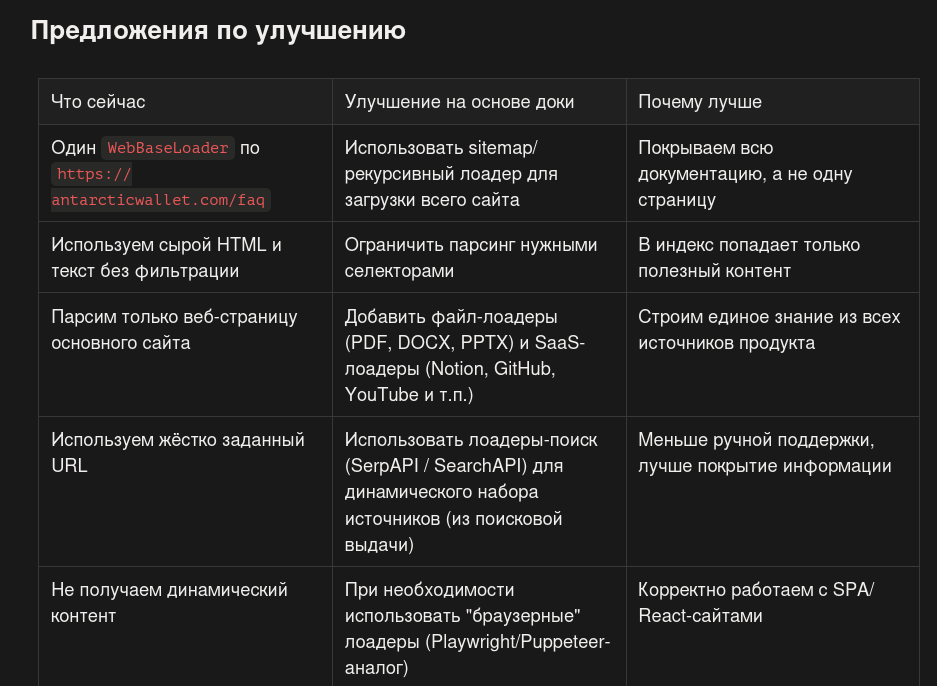



### Итоговый код

Для примера мы добавим мы улучшим только часть с тем, что мы парсим всего одну страницу. 

У большинства сайтов есть файл `sitemap.xml`.

Это официальный список всех страниц, которые сайт хочет индексировать (Google работает так же).

**SitemapLoader делает ровно то, что нужно для RAG:**

1. Скачивает `sitemap.xml`;
2. Достаёт из него все URL;
3. Загружает каждую страницу;
4. Возвращает список `Document` – по одному на страницу.

Таким образом: 

- Мы ничего не "придумываем"
- Не ходим по внешним ссылкам
- Получаем весь сайт целиком

https://mt-lab.su/ -- main

https://mt-lab.su/sitemap.xml | имеем три варианта (каталоги, продукты, о компании)

<sitemapindex>
<sitemap>
<loc>
https://mt-lab.su/sitemap-part-categories-index.xml --------> https://mt-lab.su/sitemap-part-categories-chunk-0.xml
</loc>
</sitemap>
<sitemap>
<loc>
https://mt-lab.su/sitemap-part-products-index.xml --------> https://mt-lab.su/sitemap-part-products-chunk-0.xml
</loc>
</sitemap>
<sitemap>
<loc>
https://mt-lab.su/sitemap-pages.xml --------> https://mt-lab.su/sitemap-pages.xml
</loc>
</sitemap>
</sitemapindex>


In [ ]:
# Загрузка документов
import os
from langchain_community.document_loaders import SitemapLoader, RecursiveUrlLoader

os.environ["USER_AGENT"] = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"

ROOT_URL = "https://mt-lab.su/"
SITEMAP_URL = f"{ROOT_URL}/sitemap-part-categories-chunk-0.xml" # один из sitemap, который точно существует

# # 1) Загружаем все страницы из sitemap
# sitemap_loader = SitemapLoader(
#     web_path=SITEMAP_URL,
#     filter_urls=[ROOT_URL],  # на всякий случай ограничиваем доменом
# )

# sitemap_docs = sitemap_loader.load()

# only one page in sitemap
# Total documents: 18
# Total characters: 26043

# 2) Дополнительно рекурсивно обходим сайт от корня
recursive_loader = RecursiveUrlLoader(
    url=ROOT_URL,
    max_depth=3,          # глубину при желании можно увеличить
    prevent_outside=True  # не выходим за пределы домена
)
recursive_docs = recursive_loader.load()

# depth=2
# Total documents: 29
# Total characters: 2808801

# depth=3
# Total documents: 34
# Total characters: 3160292


# # 3) Объединяем всё в один список документов для RAG
# # docs = sitemap_docs + recursive_docs
# docs = recursive_docs

print(f"Total documents: {len(recursive_docs)}")
print(f"Total characters: {sum(len(doc.page_content) for doc in recursive_docs)}")

Total documents: 34
Total characters: 3160292


# Разделение документов на кусочки (split)

## 1. Что делает text splitter в RAG

Text splitter – это слой между "сырыми" документами и эмбеддингами. Его задача:

- **разбить длинный текст на кусочки**, которые:
    - поместятся в контекст модели,
    - можно доставать по отдельности из векторного хранилища;
- **сохранить смысл и структуру** внутри каждого кусочка (не рвать предложения и логические блоки, где это возможно).

В LangChain рекомендуют в качестве дефолта `RecursiveCharacterTextSplitter`: он сначала пытается сохранить большие блоки (параграфы), если они не влезают – переходит на более мелкие единицы (предложения, слова).

## 2. Какие бывают стратегии разделения

В доке текстовые сплиттеры делят на три группы:

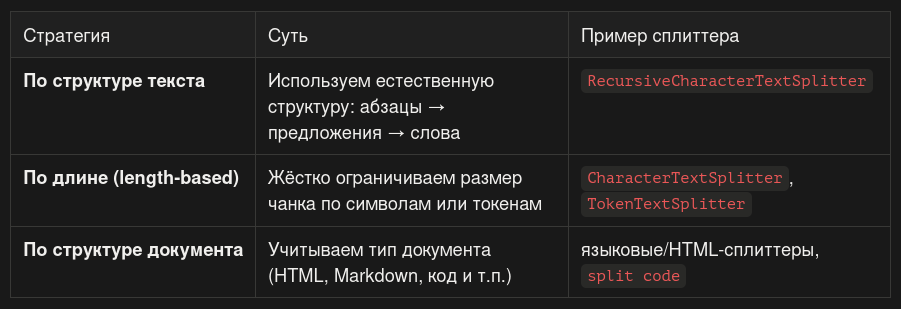

Коротко:

- **RecursiveCharacterTextSplitter** – хороший универсальный старт.
- **TokenTextSplitter** – когда важно строго уложиться в лимит токенов модели.
- **Языковые/HTML/Markdown-сплиттеры** – когда важно не рвать структуру документа (код, HTML, Markdown и т.п.).